## Exercise 2 — **Reaction-Diffusion**

The goal of this exercise is to couple physical processes implementing:
- 1D reaction-diffusion
- Non-dimensional numbers

The goal of this exercise is to combine reaction and diffusion processes acting on the concentration of a quantity $C$. The reaction equation is an ODE, as the evolution of the quantity $C$ does not depend on the neighbouring values (or spatial gradients). Consider the following reaction ODE

$$ \frac{∂C}{∂t} = -\frac{(C-C_\mathrm{eq})}{ξ}~,$$

where $C_\mathrm{eq}$ is the equilibrium concentration and $ξ$ the reaction rate.

From what you learned in class, write an reaction-diffusion code having following physical input parameters:

```
# Physics
lx   = 20.0  # domain length
dc   = 0.1   # diffusion coefficient
ξ    = 10.0  # reaction rate
Ceq  = 0.4   # equilibrium concentration
ttot = 20.0  # total simulation time
```

Discretise your domain in 200 finite-difference cells such that the first cell centre is located at `dx/2` and the last cell centre at `lx-dx/2`. Use following explicit time step limiters:

```julia
dt   = dx^2/dc/2
```

As initial condition, define a Gaussian profile of concentration `C` of amplitude and standard deviation equal to 1, located at `lx/4`.

Update all entries of the array for the reaction process (ODE) but only inner points for the diffusion process (PDE), thus leading to the fact that boundary points will only be affected by reaction and not diffusion.

> 💡 hint: Don't forget to initialise (pre-allocate) all arrays (vectors) needed in the calculations.

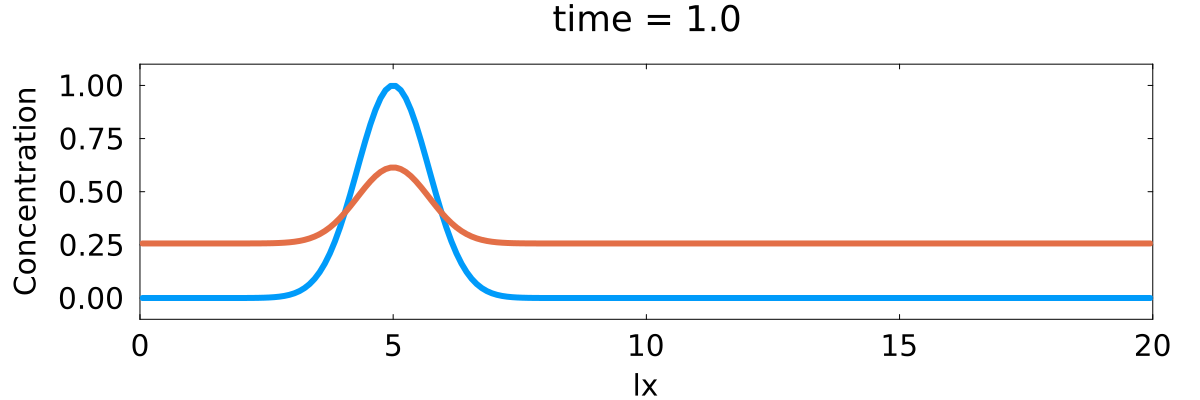

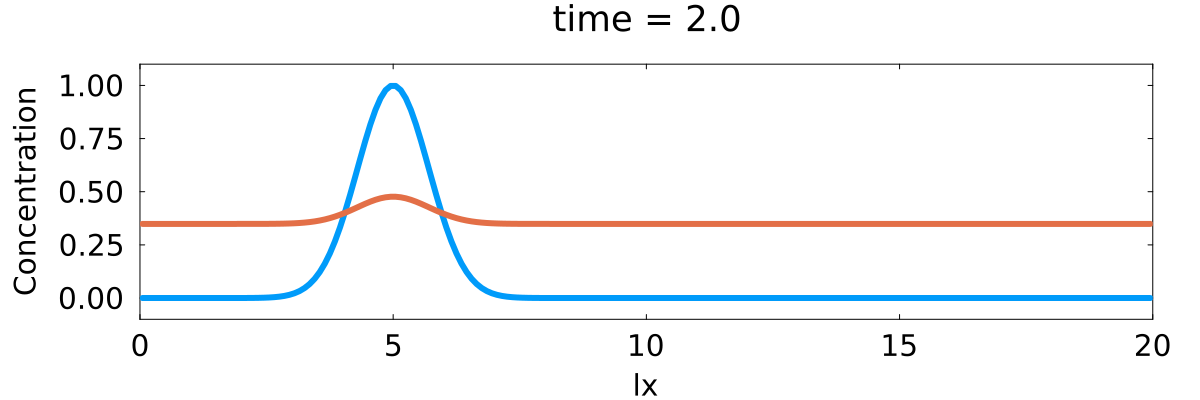

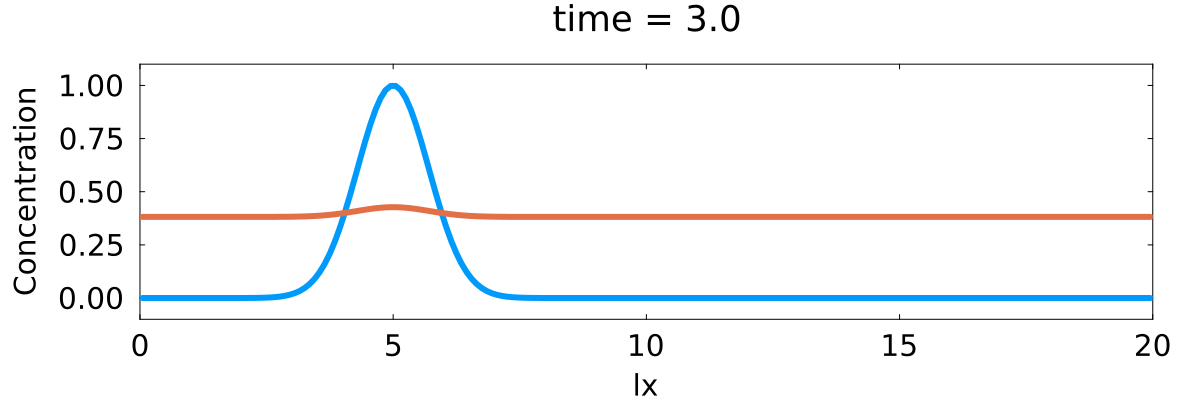

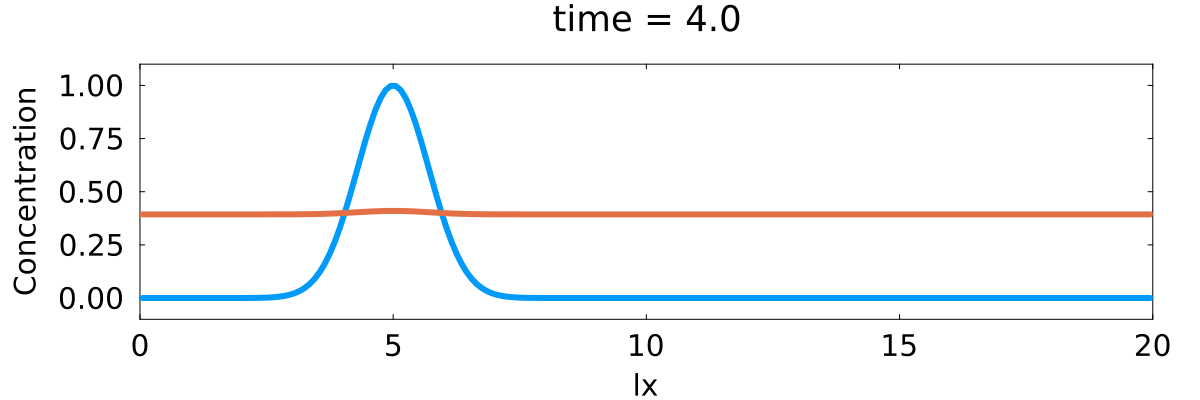

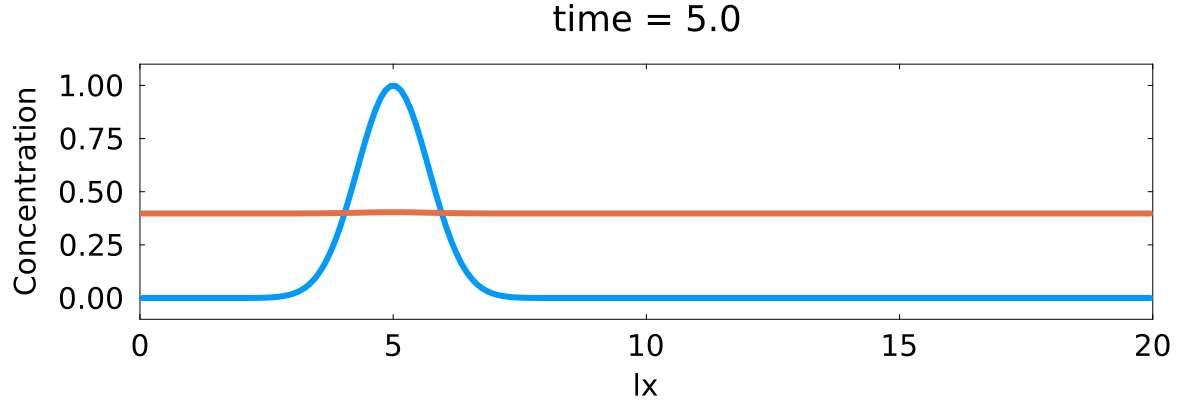

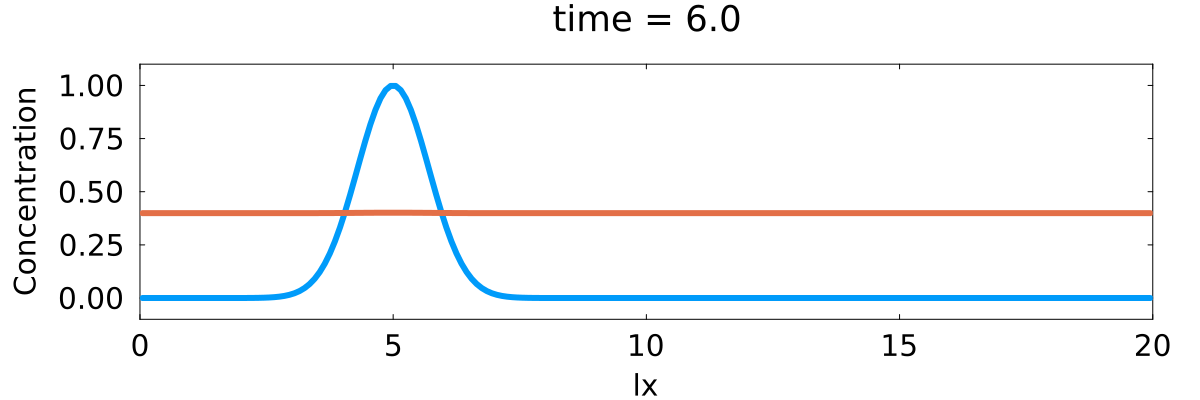

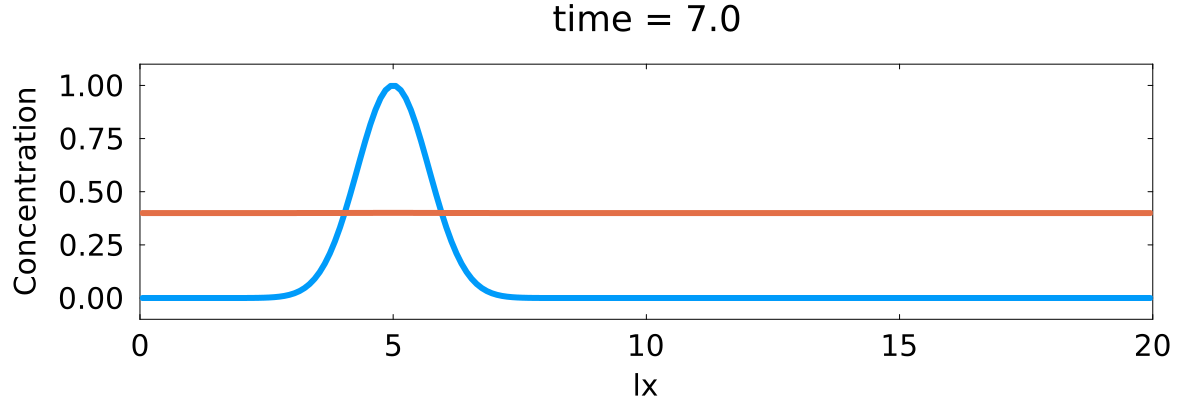

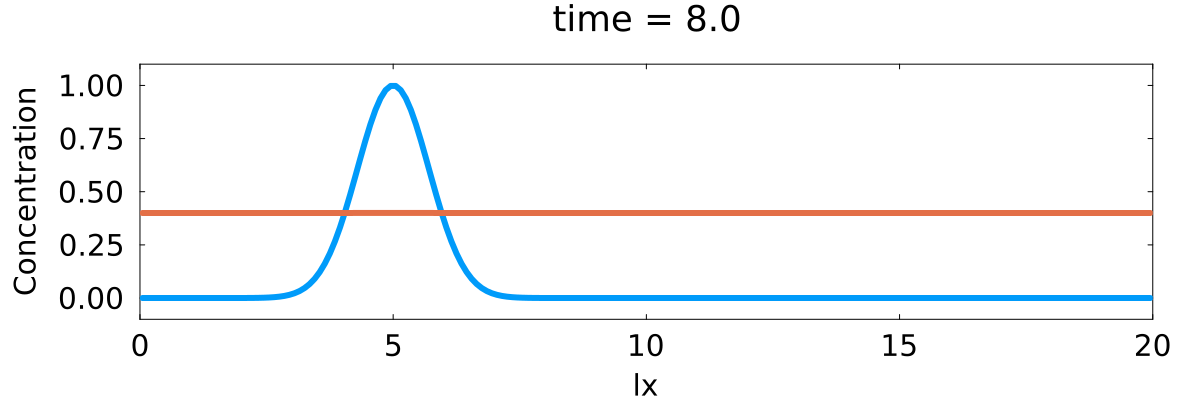

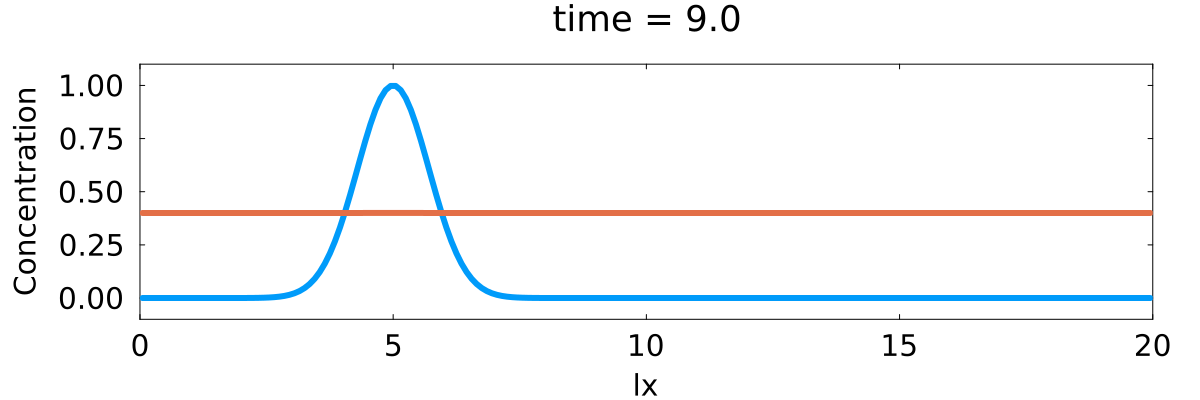

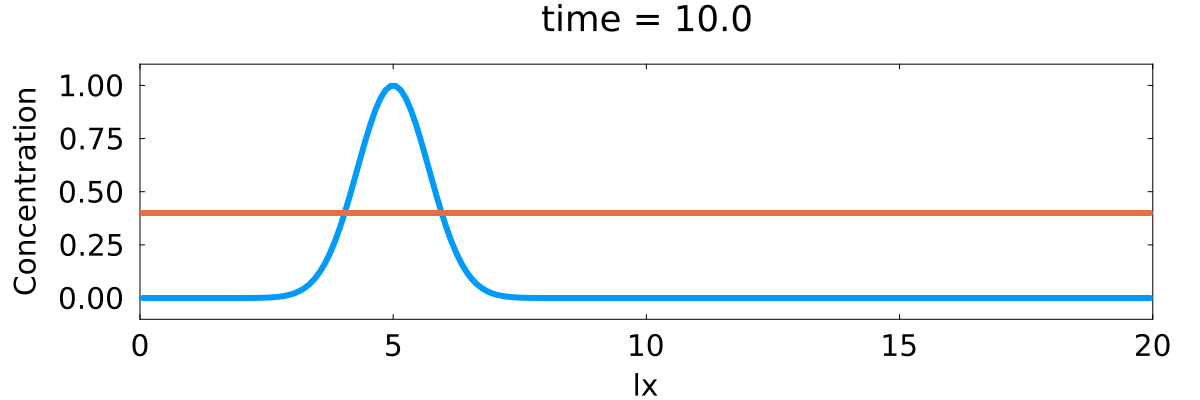

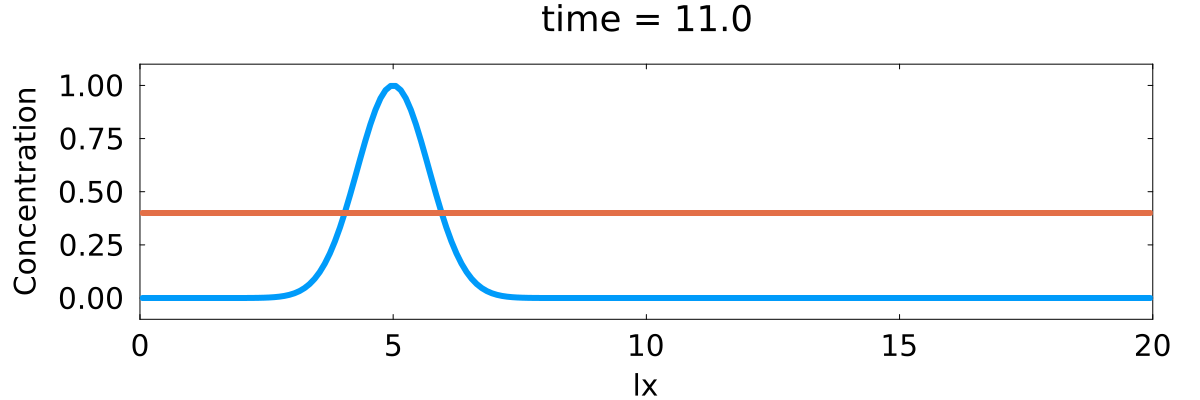

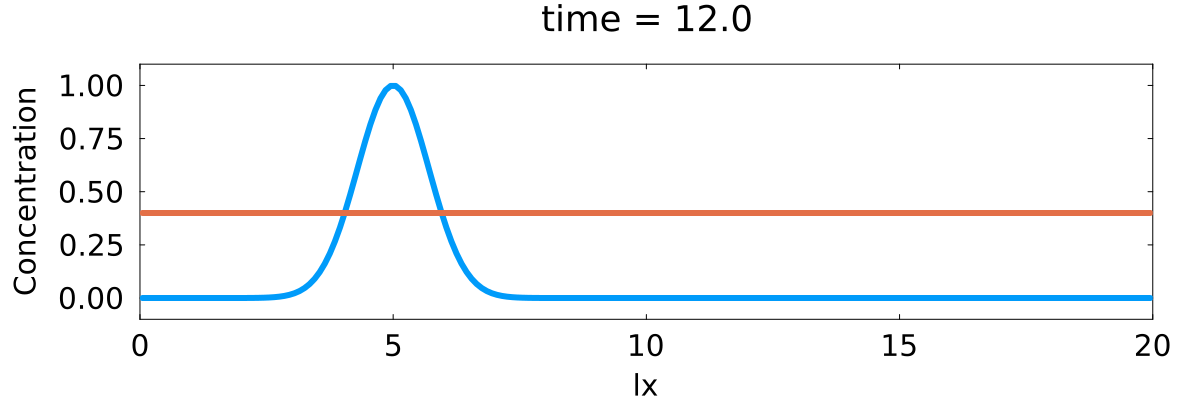

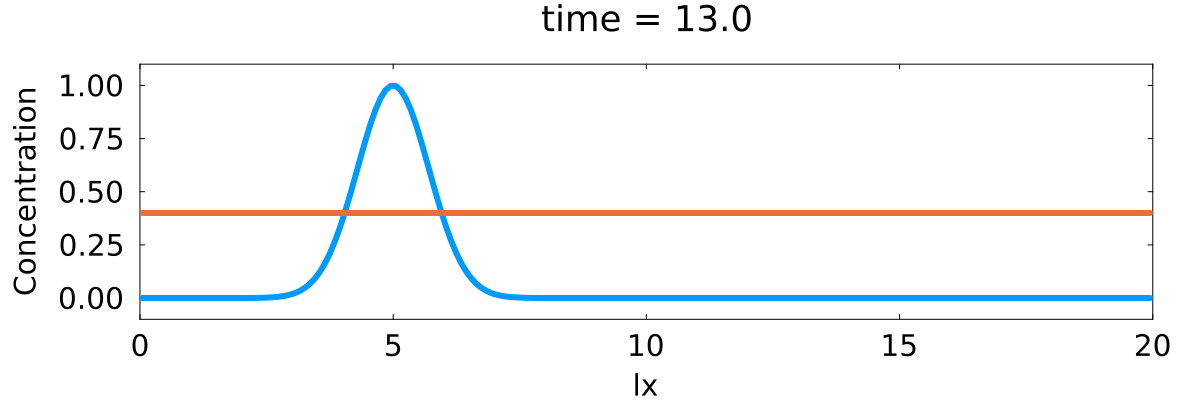

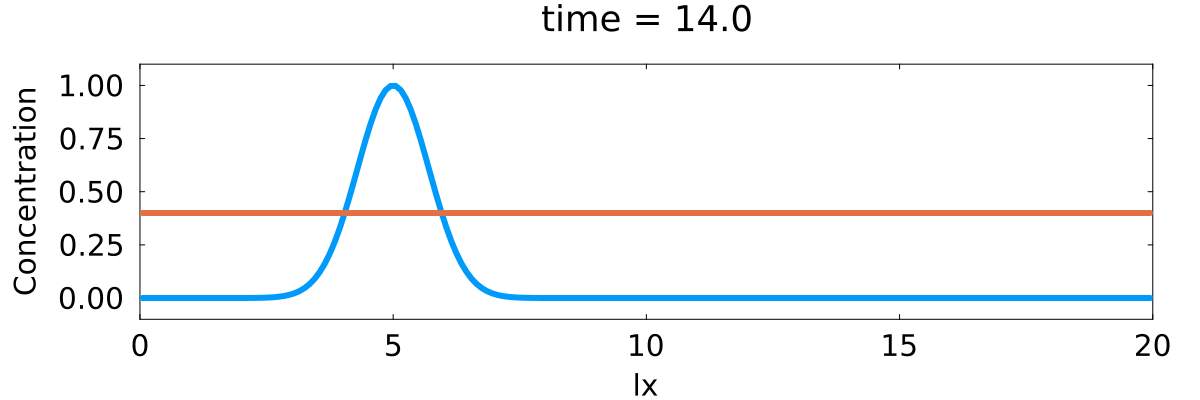

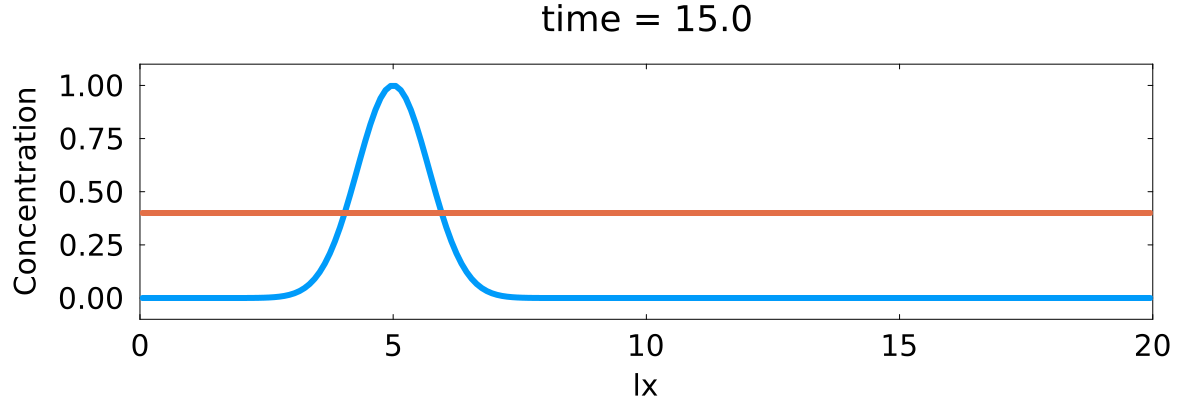

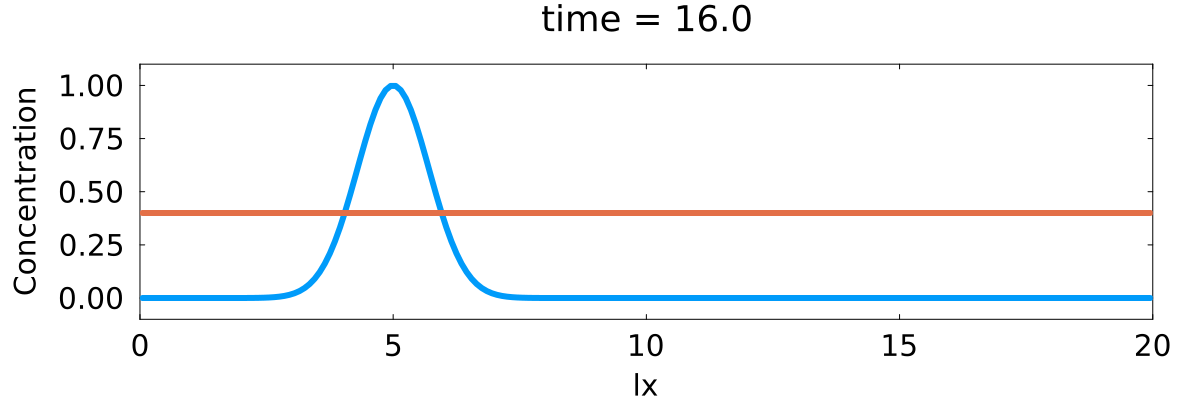

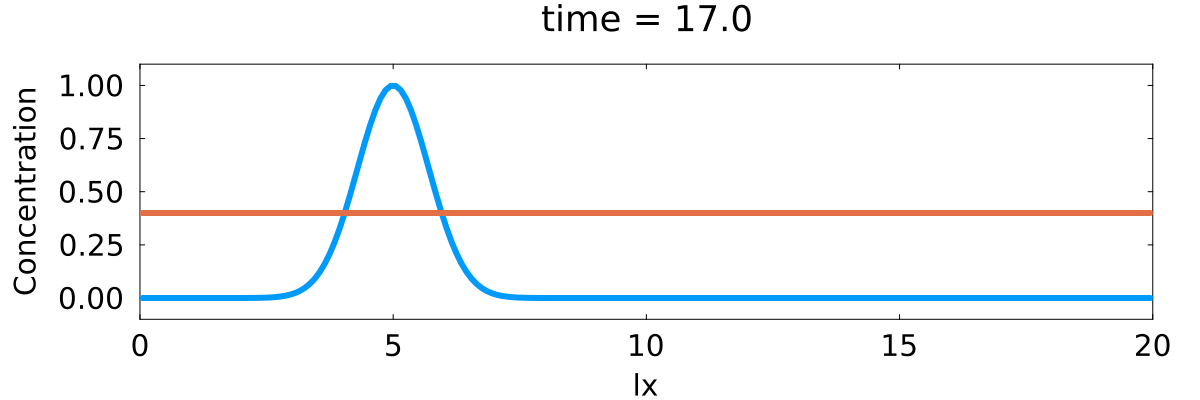

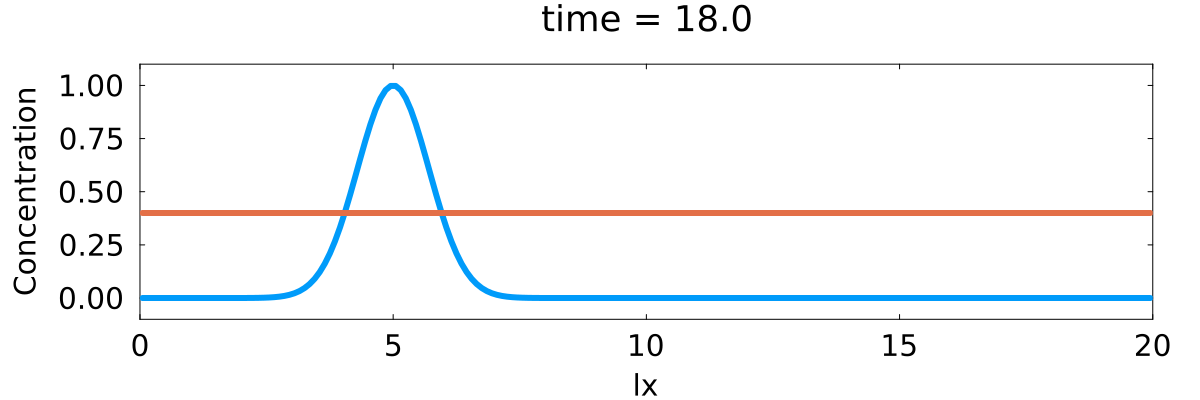

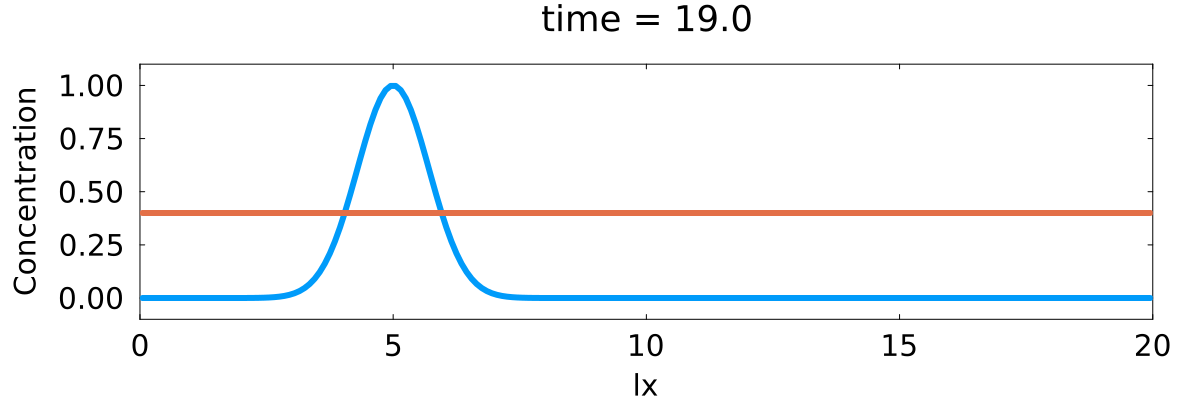

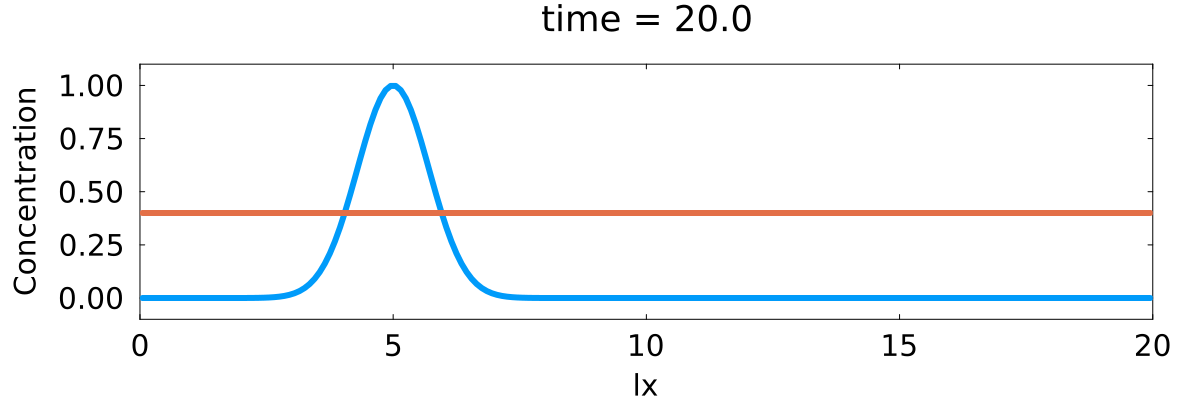

In [6]:
using Plots, Plots.Measures
default(size=(1200, 400), framestyle=:box, label=false, grid=false, margin=10mm, lw=6, labelfontsize=20, tickfontsize=20, titlefontsize=24)

@views function reactdiff()
    # Physics
    lx   = 20.0  # domain length
    dc   = 0.1   # diffusion coefficient
    ξ    = 10.0  # reaction rate
    Ceq  = 0.4   # equilibrium concentration
    ttot = 20.0  # total simulation time

    # Numerics
    nx   = 200
    dx   = lx / nx
    xc   = LinRange(dx/2, lx - dx/2, nx)
    
    # Derived Numerics
    dt   = dx^2 / dc / 2
    nt   = ttot / dt

    # Grid
    C    = @. exp(-(xc - lx/4)^2)
    C_1  = copy(C)
    q    = zeros(nx - 1)

    for it in 1:nt+1
        @. C -= dt * (C - Ceq)

        q           = -dc .* diff(C)
        C[2:nx-1] .-=  dt .* diff(q)

        if it % 20 == 0
            display(plot(xc, [C_1, C]; xlims=(0, lx), ylims=(-0.1, 1.1),
                 xlabel="lx", ylabel="Concentration",
                 title="time = $(round(it*dt,digits=1))"))
        end
    end
end

reactdiff()

### Question 1

Report the initial and final distribution of concentration on a figure with axis-label, title, and plotted line labels. Also, report on the figure (as text in one label of your choice) the maximal final concentration value and its $x$ location.

### Question 2

Repeat the exercise but introduce the non-dimensional [Damköhler number](https://en.wikipedia.org/wiki/Damköhler_numbers) $Da = lx^2/dc/ξ$ as physical quantity defining the diffusion coefficient `dc` as a `# Derived physics` quantity. Confirm the if $Da < 0.1$ most of the mass diffuses away from $C_{eq}$, and the opposite holds for $Da > 1000$.